In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [5]:
df = pd.read_csv(r"C:\Users\Srushti\Downloads\netflix_titles.csv\netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [9]:
df['date_added'] = pd.to_datetime(df['date_added'], 
errors='coerce')

In [10]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        98
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [12]:
df['country'].fillna("Unknown")
df['director'].fillna("Unknown")

0       Kirsten Johnson
1               Unknown
2       Julien Leclercq
3               Unknown
4               Unknown
             ...       
8802      David Fincher
8803            Unknown
8804    Ruben Fleischer
8805       Peter Hewitt
8806        Mozez Singh
Name: director, Length: 8807, dtype: object

In [13]:
type_counts = df['type'].value_counts()

print(type_counts)

type
Movie      6131
TV Show    2676
Name: count, dtype: int64
The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


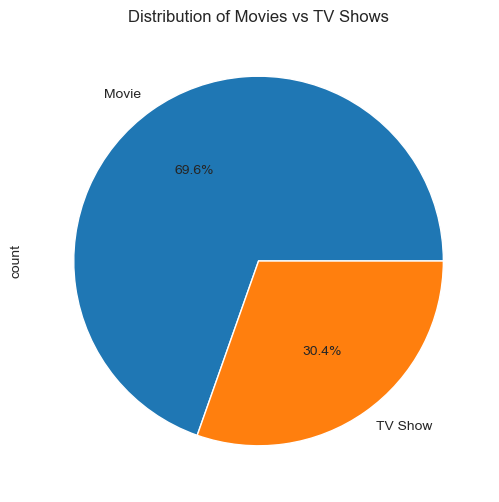

In [14]:
plt.figure(figsize=(6,6))

type_counts.plot(kind='pie', autopct='%1.1f%%')

plt.title("Distribution of Movies vs TV Shows")

plt.savefig("type_distribution.png", dpi=300)

plt.show()

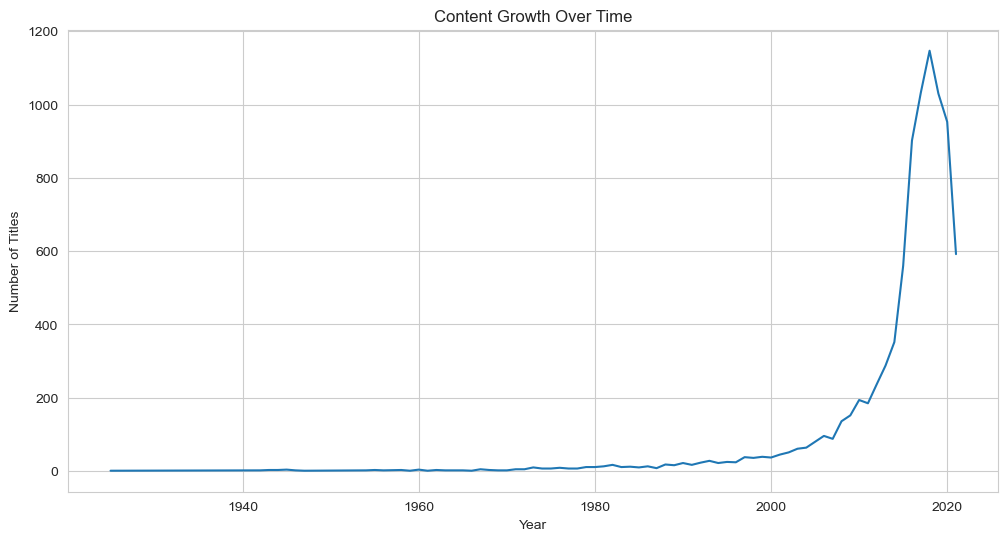

In [18]:
year_counts = df['release_year'].value_counts().sort_index()


plt.figure(figsize=(12,6))

year_counts.plot()

plt.title("Content Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.savefig("content_growth.png", dpi=300)

plt.show()

In [19]:
genres=df['listed_in'].str.split(', ')
all_genres=[]
for g in genres:
    all_genres.extend(g)
genre_series=pd.Series(all_genres)
top_genres=genre_series.value_counts().head(10)
print(top_genres)

International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


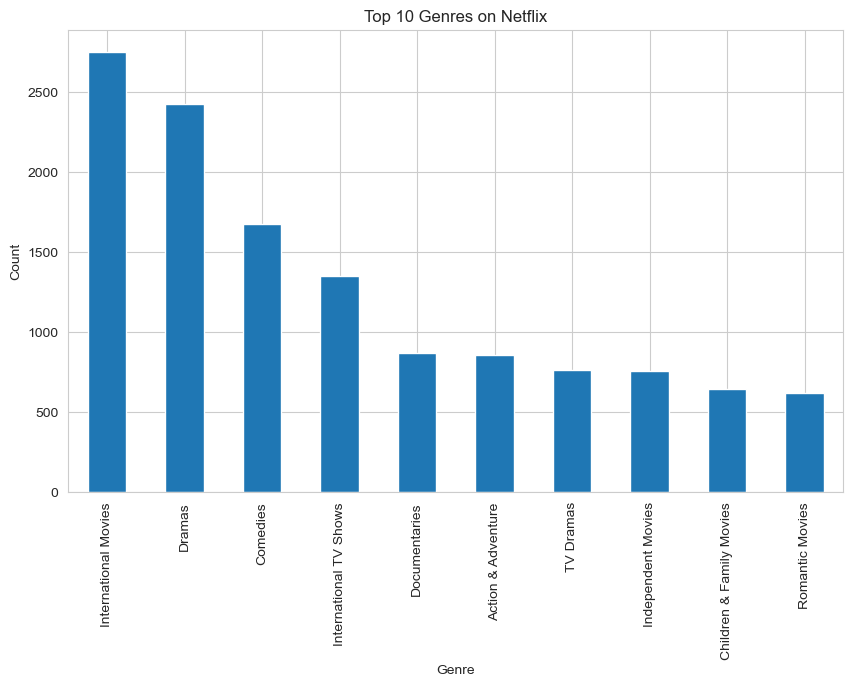

In [20]:
plt.figure(figsize=(10,6))

top_genres.plot(kind='bar')

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")

plt.savefig("top_genres.png", dpi=300)

plt.show()

In [24]:
movies = df[df['type'] == "Movie"].copy()

movies['minutes'] = movies['duration'].str.replace(" min","")

movies['minutes'] = pd.to_numeric(movies['minutes'], errors='coerce')

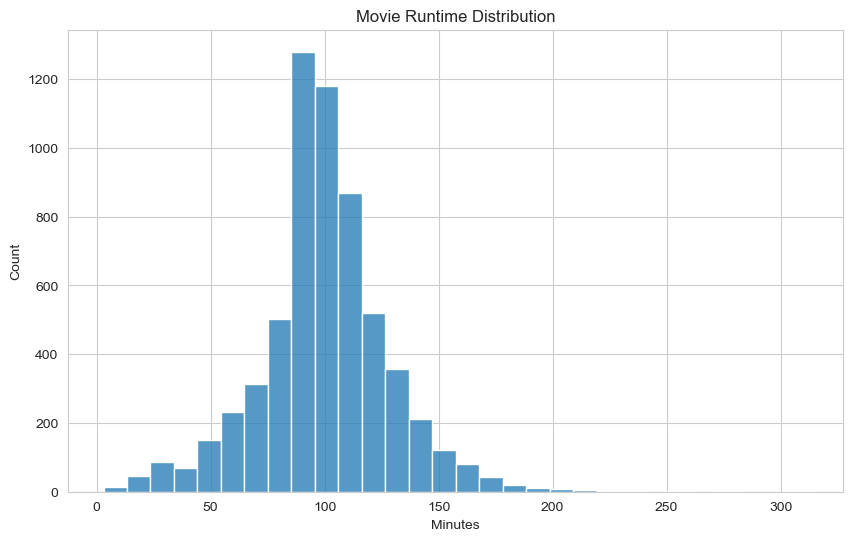

In [25]:
plt.figure(figsize=(10,6))

sns.histplot(movies['minutes'], bins=30)

plt.title("Movie Runtime Distribution")
plt.xlabel("Minutes")

plt.savefig("runtime_distribution.png", dpi=300)

plt.show()

In [26]:
top_years = df['release_year'].value_counts().head(10)

print(top_years)

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: count, dtype: int64


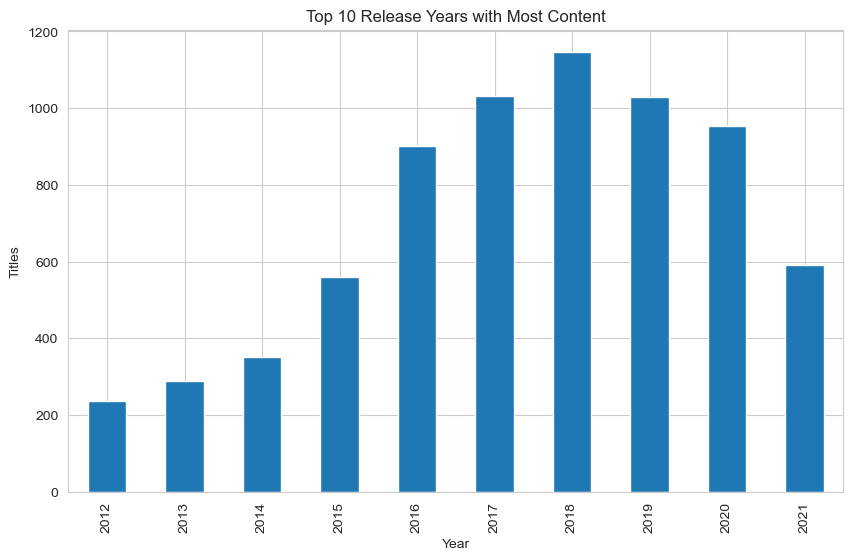

In [27]:
plt.figure(figsize=(10,6))
top_years.sort_index().plot(kind='bar')
plt.title("Top 10 Release Years with Most Content")
plt.xlabel("Year")
plt.ylabel("Titles")

plt.savefig("top_years.png",dpi=300)
plt.show()

In [28]:
top_countries=df['country'].value_counts().head(10)
print(top_countries)


country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


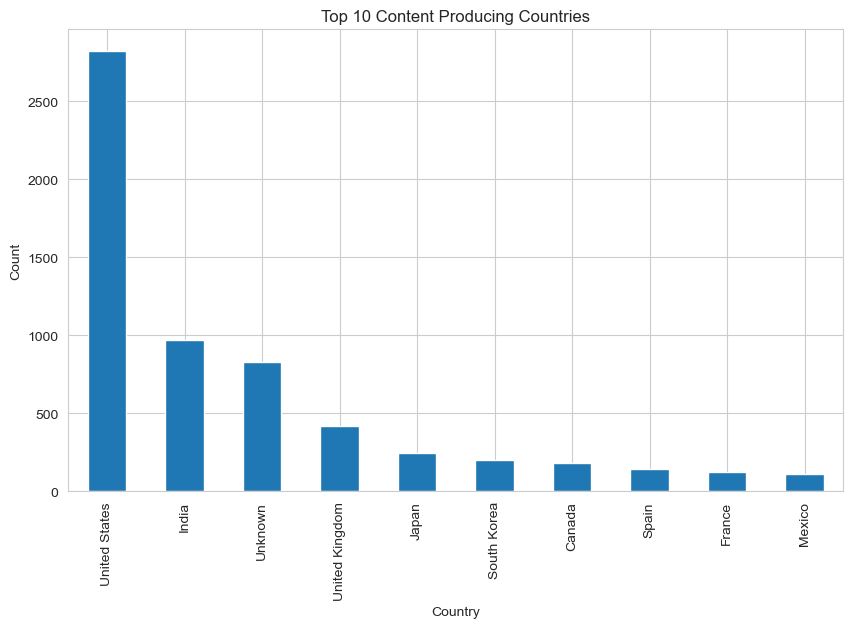

In [29]:
plt.figure(figsize=(10,6))
top_countries.plot(kind='bar')
plt.title("Top 10 Content Producing Countries")
plt.xlabel("Country")
plt.ylabel("Count")
plt.savefig("top_countries.png",dpi=300)
plt.show()